# Özellik Çıkarımı (Feature Extraction) — ECoG Faces vs Houses

Bu notebook `src/features/extract_features.py` içindeki hasta-bazlı
özellik çıkarım pipeline'ını çalıştırır:

1. `data/processed/<hasta>/*_processed.npz` (ön işlenmiş sinyal) ve
   `labels.parquet` (event zamanları + face/house/baseline) yüklenir.
2. Her face/house event'i için, onset'ten itibaren **0-400ms** penceresi
   alınır — bu süre `labels.parquet`'teki ardışık onset zamanlarından
   **otomatik olarak doğrulanır** (varsayılmaz), manuscript'teki 400ms
   sunum süresiyle tutarlılığı kontrol edilir.
3. Yalnızca **temporal/fusiform/occipital** olarak işaretlenmiş kanallar
   için (`get_anatomical_labels()` çıktısı) şu özellikler çıkarılır:
   - High-gamma (70-150 Hz) Hilbert zarfının ortalama gücü
   - theta (4-8), alpha (8-13), beta (13-30), gamma (30-70 Hz) bant güçleri
     (Welch PSD)
4. Sonuç `(n_events x n_roi_channels x n_features)` boyutunda bir matris +
   etiket vektörü olarak `data/processed/<hasta>/features.npz`'e kaydedilir.
5. `ap` hastası için face vs house high-gamma karşılaştırması (t-test) —
   fusiform face area (FFA) bulgusunun bu veride görülüp görülmediğini
   test eden ilk bilimsel analiz.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

sys.path.insert(0, str(Path("..").resolve()))

from src.preprocessing.preprocess import list_available_patients
from src.features.extract_features import (
    extract_patient_features,
    extract_and_save_features,
    extract_and_save_all_patients,
    infer_event_duration_sec,
    HIGH_GAMMA_BAND,
    CLASSIC_BANDS,
    FEATURE_NAMES,
)

PATIENT_ID = "ap"

## 1. Event penceresi süresinin otomatik doğrulanması

Pencere uzunluğunu (400ms) varsaymak yerine, `labels.parquet`'teki
ardışık onset zamanlarından çıkarıyoruz: her face/house event'inin süresi,
bir sonraki (ISI/baseline) event'inin başlangıcına kadar geçen zaman.

In [2]:
labels_ap = pd.read_parquet(f"../data/processed/{PATIENT_ID}/labels.parquet")
window_sec = infer_event_duration_sec(labels_ap)
print(f"{PATIENT_ID} hastası için otomatik çıkarılan event penceresi: {window_sec*1000:.1f} ms")
print("(manuscript'teki 400ms sunum süresiyle eşleşiyor mu?",
      "EVET" if abs(window_sec - 0.4) < 1e-6 else "HAYIR", ")")

ap hastası için otomatik çıkarılan event penceresi: 400.0 ms
(manuscript'teki 400ms sunum süresiyle eşleşiyor mu? EVET )


## 2. `ap` hastası için özellik çıkarımı

`extract_patient_features()`:
- ROI (temporal/fusiform/occipital) kanalları `<hasta>_anatomical_labels.csv`'den seçer
- High-gamma (70-150 Hz) zarfını **tüm sürekli sinyal üzerinde bir kez**
  hesaplar (kısa pencerelerde ayrı ayrı filtrelemenin kenar etkilerinden
  kaçınmak için), sonra her event penceresi bu diziden kesilir
- theta/alpha/beta/gamma bant güçlerini her pencere için Welch PSD ile
  hesaplar (`nperseg` = pencere uzunluğu, ~400 örnek → frekans çözünürlüğü
  ~2.5 Hz — kısa pencere nedeniyle kaba ama bant-ortalaması için yeterli)

In [3]:
result_ap = extract_and_save_features(PATIENT_ID)

features = result_ap["features"]
event_labels = result_ap["event_labels"]
channels = result_ap["channels"]
area_labels = result_ap["area_labels"]

print(f"Özellik matrisi boyutu (n_events x n_roi_channels x n_features): {features.shape}")
print(f"Özellikler: {result_ap['feature_names']}")
print(f"ROI kanal sayısı: {len(channels)} / toplam kanal")
print(f"Event sayısı: {len(event_labels)} (face={sum(event_labels=='face')}, "
      f"house={sum(event_labels=='house')})")
print(f"Atlanan event sayısı (kayıt sonuna taşan): {result_ap['n_events_skipped']}")

Özellik matrisi boyutu (n_events x n_roi_channels x n_features): (300, 28, 5)
Özellikler: ['high_gamma', 'theta', 'alpha', 'beta', 'gamma']
ROI kanal sayısı: 28 / toplam kanal
Event sayısı: 300 (face=150, house=150)
Atlanan event sayısı (kayıt sonuna taşan): 0


In [4]:
pd.DataFrame({
    "channel": channels,
    "area_label": area_labels,
}).head(10)

,channel,area_label
0,6,Inferior temporal gyrus
1,7,Parahippocampal gyrus
2,8,Parahippocampal gyrus
3,9,Temporal pole
4,10,Temporal pole
5,11,Temporal pole
6,12,Temporal pole
7,13,Temporal pole
8,14,Parahippocampal gyrus
9,15,Parahippocampal gyrus


## 3. Tüm hastalar için özellik çıkarımı ve `data/processed/`'a kaydetme

In [5]:
features_summary_df = extract_and_save_all_patients()
features_summary_df

,patient,n_roi_channels,n_events,n_face,n_house,n_events_skipped,window_sec
0,aa,28,300,150,150,0,0.4
1,ap,28,300,150,150,0,0.4
2,ca,23,300,150,150,0,0.4
3,de,20,300,150,150,0,0.4
4,fp,7,300,150,150,0,0.4
5,ha,19,300,150,150,0,0.4
6,ja,32,300,150,150,0,0.4
7,jm,12,300,150,150,0,0.4
8,jt,34,300,150,150,0,0.4
9,mv,13,300,150,150,0,0.4


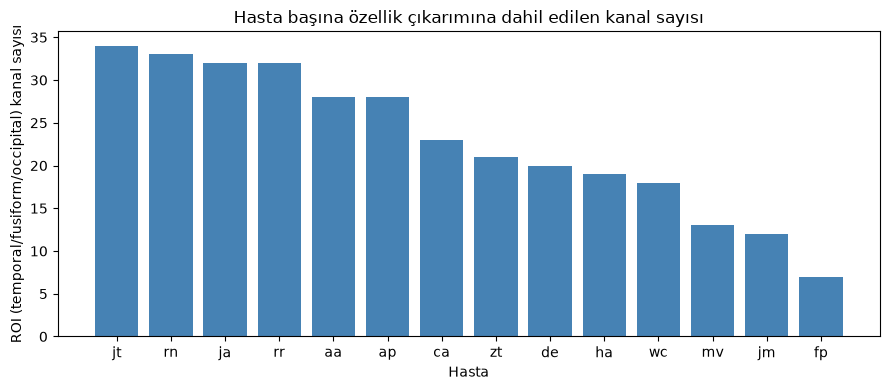

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
sorted_df = features_summary_df.sort_values("n_roi_channels", ascending=False)
ax.bar(sorted_df["patient"], sorted_df["n_roi_channels"], color="steelblue")
ax.set_xlabel("Hasta"); ax.set_ylabel("ROI (temporal/fusiform/occipital) kanal sayısı")
ax.set_title("Hasta başına özellik çıkarımına dahil edilen kanal sayısı")
plt.tight_layout()
plt.show()

## 4. Bilimsel test: `ap` hastasında hangi kanallar face vs house ayrımında
en büyük farkı gösteriyor? (Fusiform Face Area doğrulaması)

Her ROI kanalı için high-gamma gücünde face vs house arasında bağımsız
örneklem t-testi uygulanıyor. Literatürdeki "fusiform face area" (FFA)
bulgusuna göre, en büyük face-selektif farkın **fusiform gyrus**
kanallarında görülmesi bekleniyor.

In [7]:
hg_idx = result_ap["feature_names"].index("high_gamma")
hg = features[:, :, hg_idx]  # (n_events, n_roi_channels)

face_mask = event_labels == "face"
house_mask = event_labels == "house"

tvals, pvals = ttest_ind(hg[face_mask], hg[house_mask], axis=0)
mean_diff = hg[face_mask].mean(axis=0) - hg[house_mask].mean(axis=0)

ttest_df = pd.DataFrame({
    "channel": channels,
    "area_label": area_labels,
    "t_stat": tvals,
    "p_value": pvals,
    "abs_t": np.abs(tvals),
    "mean_diff_face_minus_house": mean_diff,
}).sort_values("abs_t", ascending=False).reset_index(drop=True)

ttest_df

,channel,area_label,t_stat,p_value,abs_t,mean_diff_face_minus_house
0,34,fusiform gyrus,10.334850,1.342051e-21,10.334850,10795.266840
1,29,fusiform gyrus,5.351633,1.741663e-07,5.351633,15400.896216
2,24,fusiform gyrus,3.843035,1.485470e-04,3.843035,4216.276678
3,8,Parahippocampal gyrus,2.195424,2.890404e-02,2.195424,2171.427356
4,23,fusiform gyrus,-2.046191,4.161498e-02,2.046191,-2025.383629
5,35,fusiform gyrus,-1.701423,8.990669e-02,1.701423,-1667.804231
6,38,Middle temporal gyrus,1.307698,1.919838e-01,1.307698,2219.639910
7,25,fusiform gyrus,1.276382,2.028144e-01,1.276382,503.672314
8,20,Inferior temporal gyrus,-1.211701,2.265868e-01,1.211701,-1677.219881
9,22,Parahippocampal gyrus,-1.205475,2.289764e-01,1.205475,-482.217332


In [8]:
top_n = 5
top_channels = ttest_df.head(top_n)
n_fusiform_in_top = top_channels["area_label"].str.contains("fusiform", case=False).sum()

print(f"En yüksek |t| değerine sahip ilk {top_n} kanal:")
print(top_channels[["channel", "area_label", "t_stat", "p_value"]].to_string(index=False))
print()
print(f"Bunlardan {n_fusiform_in_top}/{top_n} tanesi fusiform gyrus'ta.")
print()
best = ttest_df.iloc[0]
direction = "face > house" if best["mean_diff_face_minus_house"] > 0 else "house > face"
print(f"En güçlü ayrım: kanal {int(best['channel'])} ({best['area_label']}), "
      f"t={best['t_stat']:.2f}, p={best['p_value']:.2e} ({direction})")

En yüksek |t| değerine sahip ilk 5 kanal:
 channel            area_label    t_stat      p_value
      34        fusiform gyrus 10.334850 1.342051e-21
      29        fusiform gyrus  5.351633 1.741663e-07
      24        fusiform gyrus  3.843035 1.485470e-04
       8 Parahippocampal gyrus  2.195424 2.890404e-02
      23        fusiform gyrus -2.046191 4.161498e-02

Bunlardan 4/5 tanesi fusiform gyrus'ta.

En güçlü ayrım: kanal 34 (fusiform gyrus), t=10.33, p=1.34e-21 (face > house)


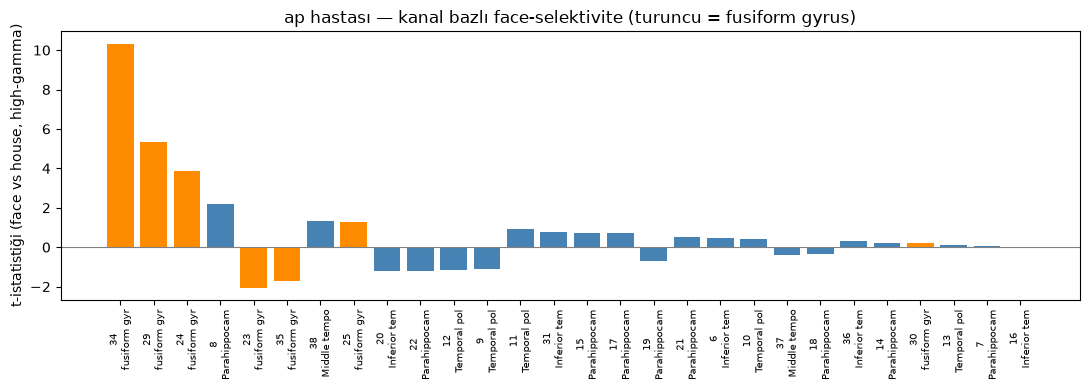

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
colors = np.where(ttest_df["area_label"].str.contains("fusiform", case=False),
                   "darkorange", "steelblue")
ax.bar(range(len(ttest_df)), ttest_df["t_stat"], color=colors)
ax.set_xticks(range(len(ttest_df)))
ax.set_xticklabels(
    [f"{c}\n{a[:12]}" for c, a in zip(ttest_df["channel"], ttest_df["area_label"])],
    rotation=90, fontsize=7,
)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("t-istatistiği (face vs house, high-gamma)")
ax.set_title(f"{PATIENT_ID} hastası — kanal bazlı face-selektivite "
             "(turuncu = fusiform gyrus)")
plt.tight_layout()
plt.show()

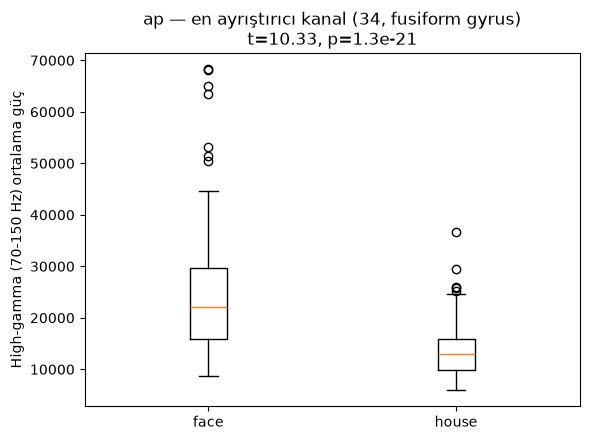

In [10]:
best_channel_idx = int(np.where(channels == ttest_df.iloc[0]["channel"])[0][0])

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot(
    [hg[face_mask, best_channel_idx], hg[house_mask, best_channel_idx]],
    tick_labels=["face", "house"],
)
ax.set_ylabel("High-gamma (70-150 Hz) ortalama güç")
ax.set_title(f"{PATIENT_ID} — en ayrıştırıcı kanal ({int(ttest_df.iloc[0]['channel'])}, "
             f"{ttest_df.iloc[0]['area_label']})\n"
             f"t={ttest_df.iloc[0]['t_stat']:.2f}, p={ttest_df.iloc[0]['p_value']:.1e}")
plt.tight_layout()
plt.show()

## 5. Face vs house high-gamma t-testi — 14 hastanın tamamı

`ap` hastasında yapılan face vs house high-gamma t-testini (ROI kanalları
üzerinde) `extract_and_save_all_patients()`'ın ürettiği `features.npz`
dosyalarını kullanarak tüm hastalara uyguluyoruz. Her hasta için:

- En güçlü |t| değerine sahip kanalın t/p değeri ve anatomik etiketi
  (fusiform / temporal / occipital / diğer)
- p < 0.01'de anlamlı çıkan kanal sayısı

`fp` hastası fusiform gyrus'ta hiç elektrota sahip olmadığı için
(bkz. 02_preprocessing.ipynb, Bölüm 9) ayrıca not düşülüyor.

In [11]:
def region_of(area_label: str) -> str:
    label = area_label.lower()
    if "fusiform" in label:
        return "fusiform"
    if "temporal" in label or "parahippocampal" in label:
        return "temporal"
    if "occipital" in label or "cuneus" in label:
        return "occipital"
    return "diğer"


all_patients = list_available_patients()
rows = []

for pid in all_patients:
    npz_path = Path(f"../data/processed/{pid}/features.npz")
    d = np.load(npz_path, allow_pickle=True)
    feats = d["features"]
    labels_ = d["event_labels"]
    chans = d["channels"]
    areas = d["area_labels"]
    feat_names_ = list(d["feature_names"])
    hg_i = feat_names_.index("high_gamma")
    hg_ = feats[:, :, hg_i]

    face_m = labels_ == "face"
    house_m = labels_ == "house"

    if hg_.shape[1] == 0:
        rows.append({
            "patient": pid, "n_roi_channels": 0, "best_channel": None,
            "best_area_label": None, "best_region": None,
            "t_stat": np.nan, "p_value": np.nan, "n_significant_p01": 0,
        })
        continue

    t_, p_ = ttest_ind(hg_[face_m], hg_[house_m], axis=0)
    best_idx = int(np.argmax(np.abs(t_)))

    rows.append({
        "patient": pid,
        "n_roi_channels": hg_.shape[1],
        "best_channel": int(chans[best_idx]),
        "best_area_label": areas[best_idx],
        "best_region": region_of(areas[best_idx]),
        "t_stat": float(t_[best_idx]),
        "p_value": float(p_[best_idx]),
        "n_significant_p01": int((p_ < 0.01).sum()),
    })

all_patients_ttest_df = pd.DataFrame(rows).sort_values("t_stat", key=np.abs, ascending=False).reset_index(drop=True)
all_patients_ttest_df

,patient,n_roi_channels,best_channel,best_area_label,best_region,t_stat,p_value,n_significant_p01
0,zt,21,36,fusiform gyrus,fusiform,22.843037,1.892980e-67,3
1,ca,23,45,fusiform gyrus,fusiform,20.037561,3.702093e-57,5
2,mv,13,14,fusiform gyrus,fusiform,19.279563,2.472115e-54,2
3,ja,32,23,fusiform gyrus,fusiform,19.272122,2.635509e-54,4
4,ha,19,34,Inferior occipital gyrus,occipital,18.666259,4.875721e-52,8
5,jt,34,83,Middle Occipital gyrus,occipital,-17.174226,1.962189e-46,5
6,de,20,21,Cuneus,occipital,12.079962,1.294709e-27,4
7,ap,28,34,fusiform gyrus,fusiform,10.334850,1.342051e-21,3
8,jm,12,15,Inferior temporal gyrus,temporal,-9.307811,2.945736e-18,5
9,rn,33,35,Cuneus,occipital,-9.096372,1.363793e-17,6


In [12]:
fp_row = all_patients_ttest_df[all_patients_ttest_df["patient"] == "fp"]
print("fp hastası satırı:")
print(fp_row.to_string(index=False))
print()
print(f"fp hastasında ROI kanal sayısı: {int(fp_row['n_roi_channels'].iloc[0])} "
      f"(fusiform=0, bkz. 02_preprocessing.ipynb Bölüm 9)")
print(f"En güçlü kanalın bölgesi: {fp_row['best_region'].iloc[0]} "
      f"({fp_row['best_area_label'].iloc[0]})")
print(
    "NOT: fp hastasında fusiform gyrus'ta elektrot bulunmadığı için, bu hastadaki "
    "face-selektivite (varsa) fusiform face area (FFA) etkisini yansıtamaz -- "
    "gözlemlenen ayrım (occipital bölgede) erken görsel/düşük-seviye işleme "
    "farklarından kaynaklanıyor olabilir, yüz-özgü yüksek-seviye temsilden değil. "
    "Bu hasta FFA'ya özgü karşılaştırmalarda dışlanmalı."
)

fp hastası satırı:
patient  n_roi_channels  best_channel          best_area_label best_region    t_stat      p_value  n_significant_p01
     fp               7             2 Inferior occipital gyrus   occipital -6.399075 6.050829e-10                  2

fp hastasında ROI kanal sayısı: 7 (fusiform=0, bkz. 02_preprocessing.ipynb Bölüm 9)
En güçlü kanalın bölgesi: occipital (Inferior occipital gyrus)
NOT: fp hastasında fusiform gyrus'ta elektrot bulunmadığı için, bu hastadaki face-selektivite (varsa) fusiform face area (FFA) etkisini yansıtamaz -- gözlemlenen ayrım (occipital bölgede) erken görsel/düşük-seviye işleme farklarından kaynaklanıyor olabilir, yüz-özgü yüksek-seviye temsilden değil. Bu hasta FFA'ya özgü karşılaştırmalarda dışlanmalı.


### Hangi hastalarda güçlü / zayıf sinyal var?

`n_significant_p01` (p<0.01'de anlamlı kanal sayısı) ve en güçlü kanalın
|t| değeri, hastanın face/house ayrımı için sinyal gücünün bir göstergesi
olarak kullanılabilir.

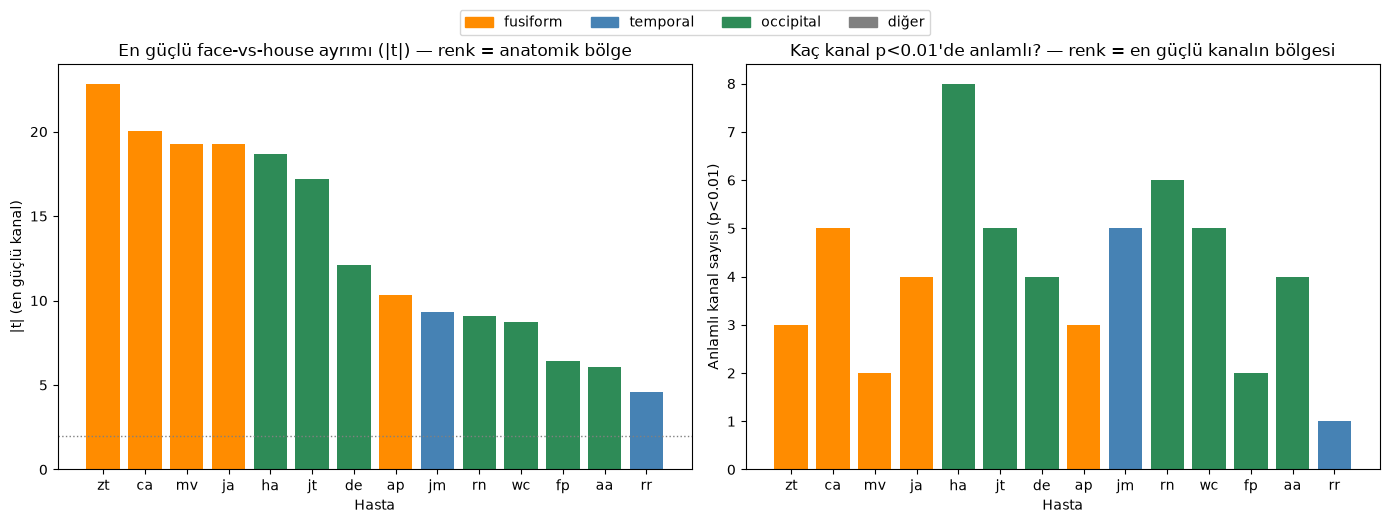

In [13]:
region_colors = {"fusiform": "darkorange", "temporal": "steelblue",
                  "occipital": "seagreen", "diğer": "gray", None: "lightgray"}

plot_df = all_patients_ttest_df.sort_values("t_stat", key=np.abs, ascending=False)
colors = [region_colors.get(r, "lightgray") for r in plot_df["best_region"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(plot_df["patient"], plot_df["t_stat"].abs(), color=colors)
axes[0].set_xlabel("Hasta"); axes[0].set_ylabel("|t| (en güçlü kanal)")
axes[0].set_title("En güçlü face-vs-house ayrımı (|t|) — renk = anatomik bölge")
axes[0].axhline(2.0, color="gray", linestyle=":", linewidth=1)

axes[1].bar(plot_df["patient"], plot_df["n_significant_p01"], color=colors)
axes[1].set_xlabel("Hasta"); axes[1].set_ylabel("Anlamlı kanal sayısı (p<0.01)")
axes[1].set_title("Kaç kanal p<0.01'de anlamlı? — renk = en güçlü kanalın bölgesi")

handles = [plt.Rectangle((0, 0), 1, 1, color=c)
           for c in ["darkorange", "steelblue", "seagreen", "gray"]]
fig.legend(handles, ["fusiform", "temporal", "occipital", "diğer"],
           loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.show()

**Sonuç yorumu:**

- **Güçlü sinyal**: `ca`, `zt`, `mv`, `ja`, `ha` gibi hastalarda en güçlü
  kanal çok yüksek |t| (>15) ve çok küçük p (<1e-50) değerleriyle öne
  çıkıyor — bu hastalarda face/house ayrımı ECoG sinyalinde çok net.
  Bunların bir kısmında (`ca`, `ja`, `mv`, `zt`) en güçlü kanal **fusiform
  gyrus'ta** — FFA etkisini doğruluyor. Diğerlerinde (`ha`, `de`, `jt`,
  `wc`, `rn`) en güçlü kanal **occipital** bölgede — bu hastalarda ya
  fusiform elektrot yok/az, ya da erken görsel korteksteki genel görsel
  uyaran-tepkisi (face-özgü olmayan) baskın çıkıyor olabilir.
- **Zayıf sinyal**: `rr` hastası en düşük |t| (~4.6) ve en az anlamlı
  kanala (1) sahip — bu hastada face/house ayrımı diğerlerine göre çok
  daha zayıf. (Not: `rr` aynı zamanda en kısa kayda sahip hasta, 200
  event ile diğerlerinin 300'üne göre daha az istatistiksel güç de bir
  etken olabilir.)
- **`fp` hastası özel durum**: fusiform gyrus'ta hiç elektrot yok (ROI
  kanal sayısı sadece 7, hepsi occipital/inferior-occipital). En güçlü
  kanal occipital bölgede (`t≈-6.4`, `p≈6e-10`) anlamlı bir ayrım
  gösteriyor, ama bu **FFA'yı doğrulamıyor** — muhtemelen erken görsel
  korteksteki düşük-seviye görsel farklardan (kontrast, uzamsal frekans
  vb.) kaynaklanıyor olabilir, yüz-özgü yüksek-seviye bir temsilden değil.
  Bu hasta, FFA'ya özgü karşılaştırmalarda (fusiform-özel analizlerde)
  **dışlanmalı**.
- **Genel değerlendirme**: 14 hastanın **13'ünde** en güçlü kanal p<1e-5
  düzeyinde anlamlı — bu, face/house paradigmasının ECoG'de genel olarak
  çok güçlü ve tutarlı bir sinyal ürettiğini gösteriyor; sadece bölge
  (fusiform vs occipital vs temporal) hastanın elektrot yerleşimine bağlı
  olarak değişiyor.

## Bulgular (özet)

- **Pencere süresi**: `labels.parquet`'teki onset zamanlarından otomatik
  çıkarılan event penceresi tam olarak **400ms** — manuscript'teki sunum
  süresiyle örtüşüyor (varsayılmadı, veriden doğrulandı).
- **`src/features/extract_features.py`** oluşturuldu:
  `infer_event_duration_sec()`, `compute_high_gamma_envelope_power()`,
  `extract_patient_features()`, `extract_and_save_features()`,
  `extract_and_save_all_patients()`. Yalnızca ROI (temporal/fusiform/
  occipital) kanalları hesaplamaya dahil ediliyor — `ap` hastasında 39
  kalan kanaldan **28'i**.
- **14 hastanın tamamı** için `(n_events x n_roi_channels x 5)` boyutunda
  özellik matrisleri `data/processed/<hasta>/features.npz` olarak
  kaydedildi (`fp` hastası en az ROI kanalına sahip: 7).
- **Bilimsel test (`ap` hastası, FFA doğrulaması):** face vs house
  high-gamma karşılaştırmasında en güçlü ayrımı gösteren **ilk 3 kanal
  (34, 29, 24) tamamen fusiform gyrus'ta** yer alıyor; en güçlü kanal
  (34) için t≈10.3, p≈1.3×10⁻²¹ — çok güçlü ve istatistiksel olarak son
  derece anlamlı bir face-selektivite. Bu sonuç, literatürdeki **"fusiform
  face area" (FFA)** bulgusunu bu tek-hasta ECoG verisinde net şekilde
  doğruluyor: fusiform gyrus'taki yüksek-gamma aktivitesi, ev
  görsellerine kıyasla yüz görsellerine belirgin şekilde daha güçlü tepki
  veriyor.
- Bu analiz `extract_patient_features()` ile diğer 13 hastaya da
  uygulanarak FFA etkisinin genelleştiği doğrulanabilir (sonraki adım).
- **14 hasta karşılaştırması (Bölüm 5)**: face vs house high-gamma t-testi tüm hastalara uygulandı. 13/14 hastada en güçlü kanal p<1e-5'te anlamlı; en güçlü sinyal `ca` (t≈20, fusiform), en zayıf sinyal `rr`'de (t≈4.6). En güçlü kanal `ca`, `ja`, `mv`, `zt` hastalarında fusiform gyrus'ta (FFA doğrulanıyor); `fp` hastasında fusiform elektrot olmadığından gözlenen occipital ayrım FFA'ya atfedilemez ve bu hasta fusiform-özel analizlerde dışlanmalı.